In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
class DeepSet(nn.Module):
    def __init__(self, in_dim, h_dim, out_dim, aggr_type):
        super().__init__()

        self.phi = nn.Sequential(
            nn.Linear(in_dim, h_dim),
            nn.ReLU(),
            nn.Linear(h_dim, h_dim),
            nn.ReLU(),
            nn.Linear(h_dim, h_dim),
            nn.ReLU()
        )
        self.rho = nn.Sequential(
            nn.Linear(h_dim, h_dim),
            nn.ReLU(),
            nn.Linear(h_dim, h_dim),
            nn.ReLU(),
            nn.Linear(h_dim, out_dim)
        )

        """self.phi = nn.Sequential(
            nn.Linear(in_dim, 200),
            nn.ReLU(),
            nn.Linear(200, 100),
            nn.ReLU(),
            nn.Linear(100, 50),
            nn.ReLU()
        )
        self.rho = nn.Sequential(
            nn.Linear(50, 25),
            nn.ReLU(),
            nn.Linear(25, 12),
            nn.ReLU(),
            nn.Linear(12, out_dim)
        )"""

        self.aggr_type = aggr_type

    def forward(self, x, mask=None):

        h = self.phi(x)

        if mask is not None:
            h = h * mask.unsqueeze(-1)
            
        if self.aggr_type == 'sum':
            s = h.sum(dim=1)
        elif self.aggr_type == 'max':
            s, _ = h.max(dim=1)
        elif self.aggr_type == 'mean':
            s = h.mean(dim=1)
        else:
            raise ValueError('Unknown aggregation type')

        return self.rho(s)

class CondSM(nn.Module):

    def __init__(
        self,
        layer_dims,
        dropout_p: float = 0.2,
        batch_norm: bool = True,
    ):
        super().__init__()

        self.layer_dims = layer_dims
        self.in_features = layer_dims[0]
        self.out_features = layer_dims[-1]
        self.num_layers = len(layer_dims)

        self.dropout_p = float(dropout_p)
        self.batch_norm = bool(batch_norm)

        self.model = self._build_model()
        self._reset_parameters()

    def _build_model(self) -> nn.Sequential:
        layers = []
        for k in range(1, len(self.layer_dims)):
            in_dim = self.layer_dims[k - 1]
            out_dim = self.layer_dims[k]

            layers.append(nn.Linear(in_dim, out_dim, bias=True))

            if k < self.num_layers - 1:
                if self.dropout_p > 0:
                    layers.append(nn.Dropout(self.dropout_p))
                if self.batch_norm:
                    layers.append(nn.BatchNorm1d(out_dim))
                layers.append(nn.ReLU())
                
        return nn.Sequential(*layers)

    def _reset_parameters(self):
        for m in self.model:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, a=0.0, nonlinearity="relu")
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        return self.model(x)

In [3]:
batch = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/data_uni_samples_1e6/batch_0.npz')

acc_xy = batch['acc_xy'][12]
n_a = acc_xy.shape[0]
radius = 150.0
R = np.sqrt(np.pi * radius**2 / n_a)

In [11]:
from train_sm import train_val_test_loaders, MakeDataset
from pathlib import Path

data_dir = Path('/gpfs/bwfor/work/ws/hd_gy283-my_data/data_uni_samples_1e6/')

output_idx = 0
batch_size = 512
num_batches = 200
train_size = 0.8
val_size = 0.1
test_size = 0.1

voltages = []
configurations = []
currents = []

for i in range(num_batches):

    batch = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/data_uni_samples_1e6/batch_{i}.npz')

    voltages.append(batch['inputs'])
    configurations.append(batch['acc_xy'])    

    if batch['currents'].ndim != 1:
        currents.append(batch['currents'][:, output_idx])
    else:
        currents.append(batch['currents'])

V = np.concatenate(voltages)[:, [i for i in range(voltages[0].shape[1]) if i != output_idx]]
X = np.concatenate(configurations)
y = np.concatenate(currents)

len_dataset = V.shape[0]

X = X * R / radius

X_train, X_val_test, V_train, V_val_test, y_train, y_val_test = train_test_split(X, V, y, train_size=train_size, random_state=np.random.randint(0, 2**31 - 1), shuffle=True)

X_val = X_val_test[:int(val_size*len_dataset), ...]
X_test = X_val_test[int(val_size*len_dataset):, ...]

V_val = V_val_test[:int(val_size*len_dataset), ...]
V_test = V_val_test[int(val_size*len_dataset):, ...]

y_val = y_val_test[:int(val_size*len_dataset), ...]
y_test = y_val_test[int(val_size*len_dataset):, ...]

v_mean = V_train.mean(0)
v_std = V_train.std(0)

y_mean = y_train.mean()
y_std = y_train.std()

noise_level = 0.01

if noise_level is not None and noise_level > 0.0:
    X_train = X_train + np.random.normal(loc=0.0, scale=noise_level, size=X_train.shape)
    V_train = V_train + np.random.normal(loc=0.0, scale=noise_level, size=V_train.shape)

class TwoInputDataset(Dataset):
    def __init__(self, X, V, y):
        
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.V = torch.as_tensor(V, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.float32)

        if self.y.dim() == 1:
            self.y = self.y.unsqueeze(1)

        assert len(self.X) == len(self.V) == len(self.y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.V[idx], self.y[idx]

train_set = TwoInputDataset(X_train, V_train, y_train)
val_set = TwoInputDataset(X_val, V_val, y_val)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

print(len(train_loader.dataset))

160000


In [16]:
ds_h_dim = 90
ds_out_dim = 6

num_electrodes = 7
sm_in_dim = num_electrodes + ds_out_dim
sm_h_dim = 90
sm_out_dim = 1
sm_layer_dims = [sm_in_dim, sm_h_dim, sm_h_dim, sm_h_dim, sm_out_dim]

deep_set = DeepSet(in_dim=2, h_dim=ds_h_dim, out_dim=ds_out_dim, aggr_type='sum')

'''deep_set_sq = nn.Sequential(
    DeepSet(2, ds_h_dim, ds_h_dim, 'sum'),
    DeepSet(2, ds_h_dim, ds_h_dim, 'sum'),

)'''

cond_sm = CondSM(layer_dims=sm_layer_dims, dropout_p=0.0, batch_norm=False)

deep_set = deep_set.to(device)
cond_sm = cond_sm.to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    list(deep_set.parameters()) + list(cond_sm.parameters()), 
    lr=1e-3
)

train_losses = []
val_losses = []

num_epochs = 100

with tqdm(total=num_epochs, desc="Epochs") as pbar:
    for epoch in range(1, num_epochs + 1):
    
        deep_set.train()
        cond_sm.train()
        running_loss = 0.0
        for x, v, y in train_loader:
            
            x = x.to(device, non_blocking=True).float()
            v = v.to(device, non_blocking=True).float()
            y = y.to(device, non_blocking=True).float()
            
            y = (y - y_mean) / y_std
            
            optimizer.zero_grad()
    
            z = deep_set(x)
            sm_input = torch.cat([v, z], dim=1).to(device)
            preds = cond_sm(sm_input)
    
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()
    
            running_loss += loss.item() * x.size(0)
    
        epoch_train_loss = running_loss / len(train_loader.dataset)
    
        deep_set.eval()
        cond_sm.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, v, y in val_loader:
                
                x = x.to(device, non_blocking=True).float()
                v = v.to(device, non_blocking=True).float()
                y = y.to(device, non_blocking=True).float()
                
                y = (y - y_mean) / y_std
    
                z = deep_set(x)
                sm_input = torch.cat([v, z], dim=1).to(device)
                preds = cond_sm(sm_input)
    
                loss  = criterion(preds, y)
                
                val_loss += loss.item() * x.size(0)
    
        epoch_val_loss = val_loss / len(val_loader.dataset)
    
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
    
        pbar.set_postfix({
            "epoch": f"{epoch}/{num_epochs}",
            "train": f"{epoch_train_loss:.4f}",
            "val": f"{epoch_val_loss:.4f}"
        })
        pbar.update(1)

torch.save({
    "deep_set_state_dict": deep_set.state_dict(),
    "cond_sm_state_dict": cond_sm.state_dict(),
    "train_losses": train_losses,
    "val_losses": val_losses
}, f"/gpfs/bwfor/work/ws/hd_gy283-my_data/models/conditional_sm.pth")

print(f"Model has been saved!")

Epochs: 100%|██████████| 100/100 [03:06<00:00,  1.86s/it, epoch=100/100, train=0.0394, val=0.0432]

Model has been saved!


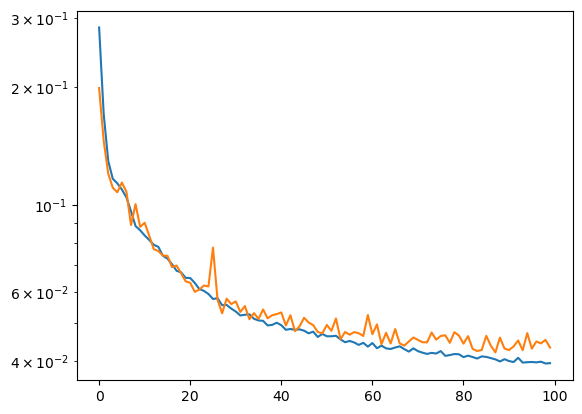

In [17]:
plt.plot(train_losses)
plt.plot(val_losses)
plt.yscale('log')

In [18]:
test_set = TwoInputDataset(X_test, V_test, y_test)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False)

deep_set.eval()
cond_sm.eval()

y_pred_l = []
y_true_l = []
latent_l = []
with torch.no_grad():
    for x, v, y in test_loader:
        x = x.to(device, non_blocking=True).float()
        v = v.to(device, non_blocking=True).float()
        y = y.to(device, non_blocking=True).float()

        z = deep_set(x)
        
        sm_input = torch.cat([v, z], dim=1)
        preds = cond_sm(sm_input).detach().cpu().numpy()
        y_pred_l.append(preds)
        y_true_l.append(y.cpu().numpy())
        latent_l.append(z.detach().cpu().numpy())

Text(0, 0.5, '$z_2$')

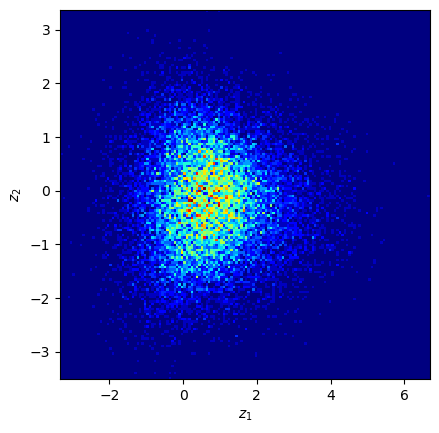

In [40]:
"""zs = np.concatenate(latent_l, axis=0)

zx_min = zs[:, 0].min()
zx_max = zs[:, 0].max()

zy_min = zs[:, 1].min()
zy_max = zs[:, 1].max()

z_ranges = [[zx_min, zx_max], [zy_min, zy_max]]

fig, ax = plt.subplots()

_, _, _, im = ax.hist2d(*zs.T, bins=150, range=z_ranges, cmap='jet')

ax.set_box_aspect(1)
ax.set_xlabel(r'$z_1$')
ax.set_ylabel(r'$z_2$')"""

0.20951690601557263
1.000671734120591


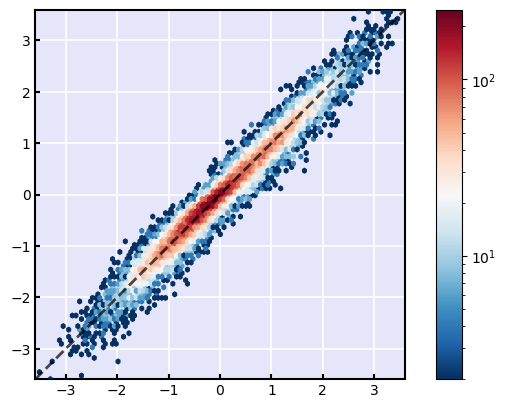

In [19]:
from utils import pred_vs_true
from matplotlib.colors import LogNorm

y_pred = np.concatenate(y_pred_l, axis=0).ravel()
y_true = np.concatenate(y_true_l, axis=0).ravel()

y_true = (y_true - y_mean) / y_std

target_mean = np.mean(y_true)

rmse = np.sqrt(np.mean((y_pred - y_true)**2))
rmse_to_mean = np.sqrt(np.mean((y_pred - y_mean)**2))

print(rmse)
print(rmse_to_mean)

lo = min(y_pred.min(), y_true.min())
hi = min(y_pred.max(), y_true.max())

plot_range = [[lo, hi], [lo, hi]]

fig, ax = plt.subplots()

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)

norm = LogNorm()

im = ax.hexbin(y_pred, y_true, bins=250, gridsize=100, norm=norm, cmap="RdBu_r", zorder=5)
#_, _, _, im = ax.hist2d(y_pred, y_true, bins=200, range=plot_range, norm=norm, cmap="RdBu", zorder=5)
ax.plot([lo, hi], [lo, hi], linestyle='--', linewidth=2, color='k', alpha=0.7, zorder=6)

fig = ax.figure
cax = fig.add_axes([ax.get_position().x1 - 0.05, ax.get_position().y0, 0.04, ax.get_position().height])
plt.colorbar(im, cax=cax)

ax.spines[:].set_linewidth(1.5)
ax.tick_params(direction='in', width=1.5)
ax.set_facecolor('lavender')
ax.grid(c='w', lw=1.2)

ax.set_aspect('equal', adjustable='box')

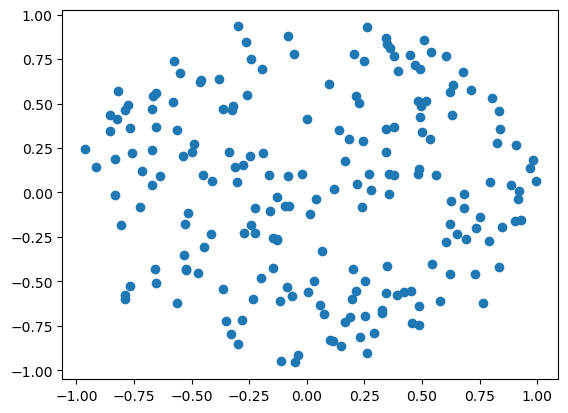

In [9]:
from utils import create_dopant_configuration

#acc_angles, don_angles, r_acc, r_don = create_dopant_configuration(radius, n_a=200, n_d=3, name_a='test_sm', name_d='test_don', mode='uniform', eps=None, save_dir='/home/hd/hd_hd/hd_gy283/kmc_project/configs/')

acc = np.loadtxt('/home/hd/hd_hd/hd_gy283/kmc_project/configs/test_sm.txt')
acc = acc / radius

plt.scatter(*acc.T)

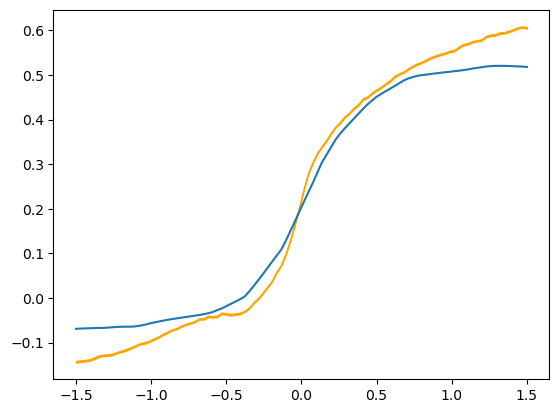

In [10]:
deep_set.eval()
cond_sm.eval()

N = 100
c_list = [0.2, 1.1, -0.5, -1, 0.5, 0.7]
c_volts = torch.tensor(c_list, dtype=torch.float32).expand(N, -1)
volt_range = torch.linspace(-1.5, 1.5, N).unsqueeze(1)

input_tensor = torch.cat([volt_range, c_volts], dim=1)
geom_tensor = torch.from_numpy(acc).float().unsqueeze(0).expand(N, 200, 2)

input_tensor = input_tensor.to(device)
geom_tensor = geom_tensor.to(device)

with torch.no_grad():
    z = deep_set(geom_tensor)    
    sm_input = torch.cat([input_tensor, z], axis=1)
    y = cond_sm(sm_input).detach().cpu().numpy()

y = y * y_std + y_mean
test_simulation = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/sm_test.npz')
current = test_simulation['current'] / 1.602176634e-19
sem = test_simulation['sem'] / 1.602176634e-19
vs = np.linspace(-1.5, 1.5, N)
plt.plot(vs, y)
plt.fill_between(vs, current-sem, current+sem, color='orange')